# Prepare the env

I haven't found the solution to load config correclty without setting *os.chdir*, so you need to change the code below with path where the project is located. 

In [1]:
import os
import sys
os.chdir('/Users/zagrebinegor/Developer/ML_Wine_Quality')  # перейти из notebooks/ в корень проекта


In [21]:
from src.preprocess import get_preprocessor
from src.utils import load_config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
config = load_config('configs/baseline.yaml')

In [4]:
data = pd.read_csv('data/processed/X_train.csv')
labels = pd.read_csv('data/processed/y_train.csv')

# Understanding the data, assessing possible changes

Let's take a look at the target values. We'll find out what it is and what values ​​it lies between.

In [5]:
labels.describe()

,quality
count,914.000000
mean,5.656455
std,0.820151
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


We see that there are no empty values, the values ​​are located in the range from 3 to 8. Now let's look at the signs to better understand their essence.

In [6]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
count,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000,914.000000
mean,8.258096,0.531018,0.265799,2.519092,0.086476,15.706783,45.838621,0.996683,3.314234,0.655646,10.439187,815.590810
std,1.696354,0.179047,0.194982,1.305725,0.047437,10.237482,31.929403,0.001914,0.152897,0.166146,1.074776,464.852449
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.400000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,412.250000
50%,7.900000,0.520000,0.250000,2.200000,0.078000,13.000000,38.000000,0.996645,3.310000,0.620000,10.200000,825.000000
75%,9.000000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.720000,11.200000,1219.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,1597.000000


In [7]:
# data.isnull().sum()
# data.duplicated()

There's no null and duplicated rows so there's no need to use Imputer in *preprocess.py* and delete any duplicated rows. But I can see, that I need to delete Id column. 

Let's analyse some data to chose the operations to preprocess. I'm going to do preprocessing using the function from *preprocess.py* and compare the values ​​before processing with the resulting value.

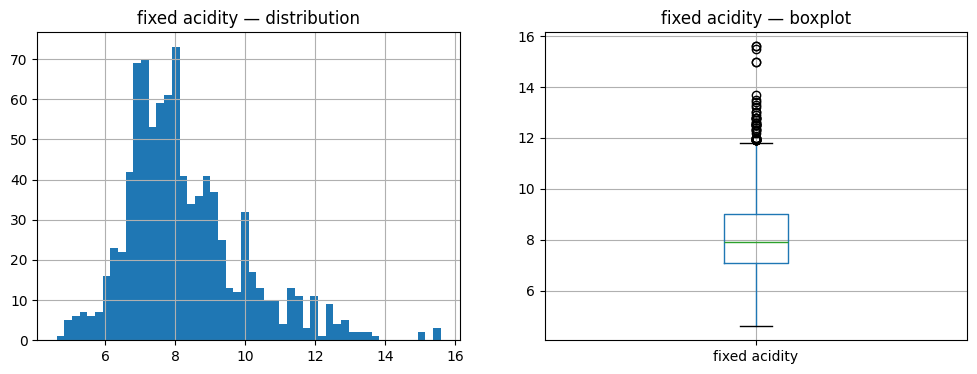

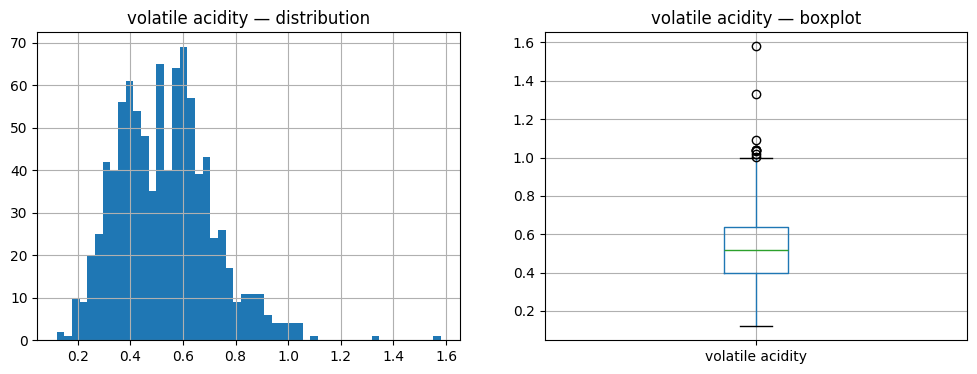

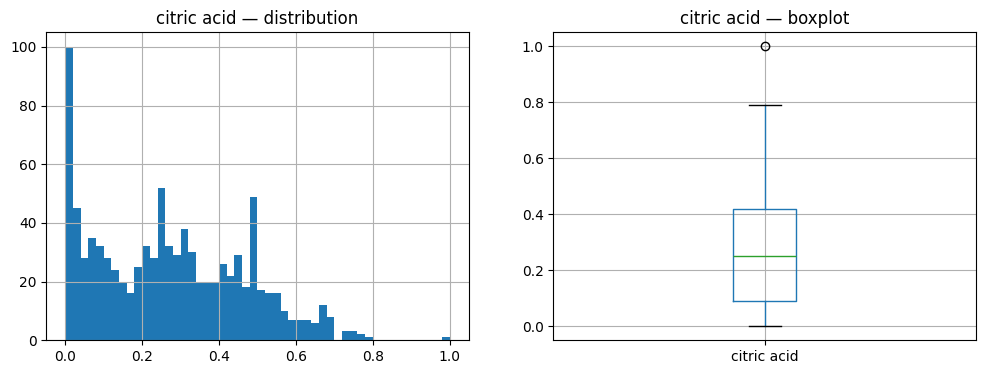

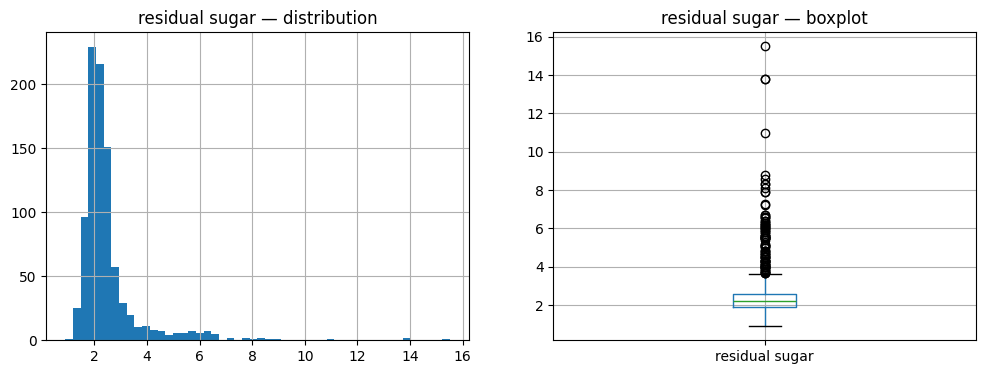

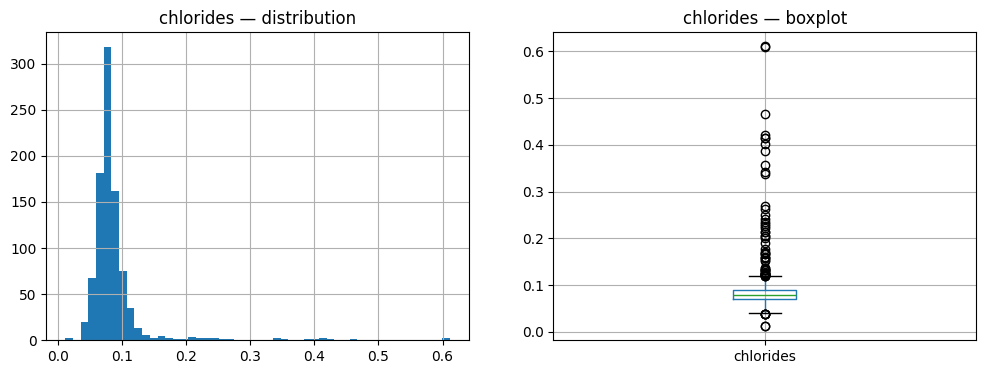

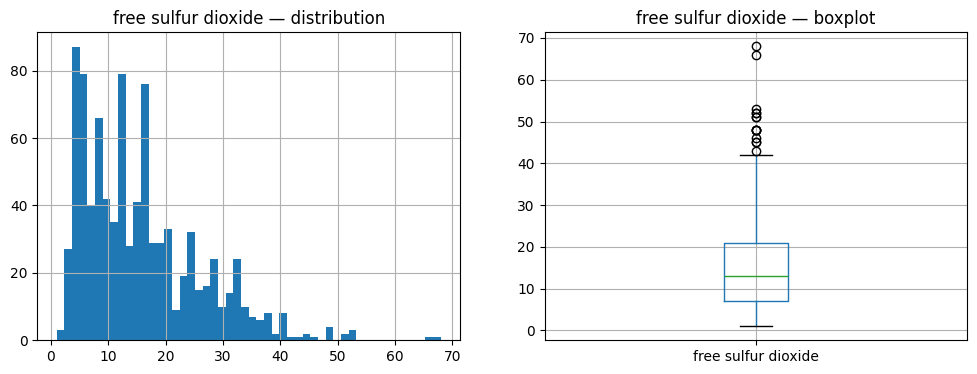

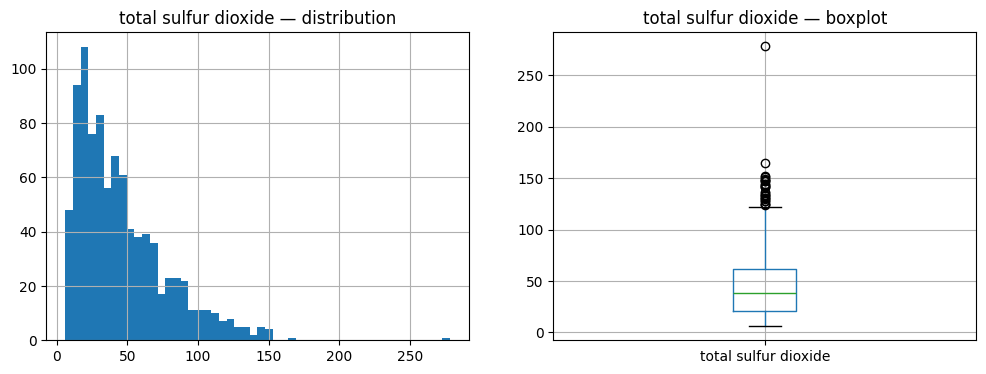

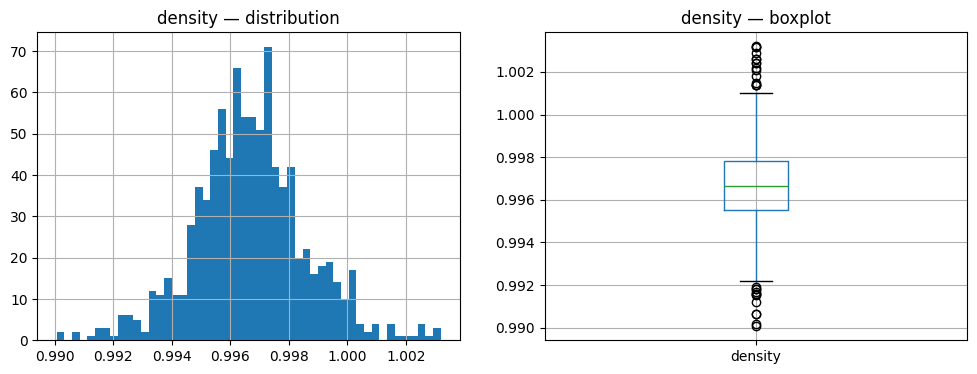

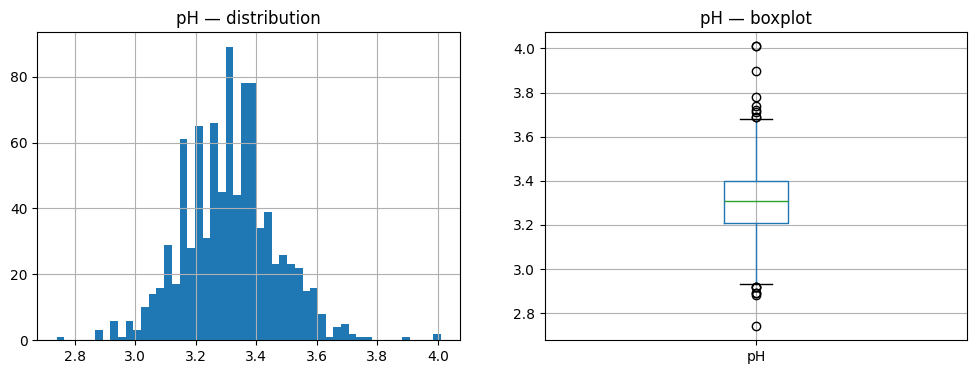

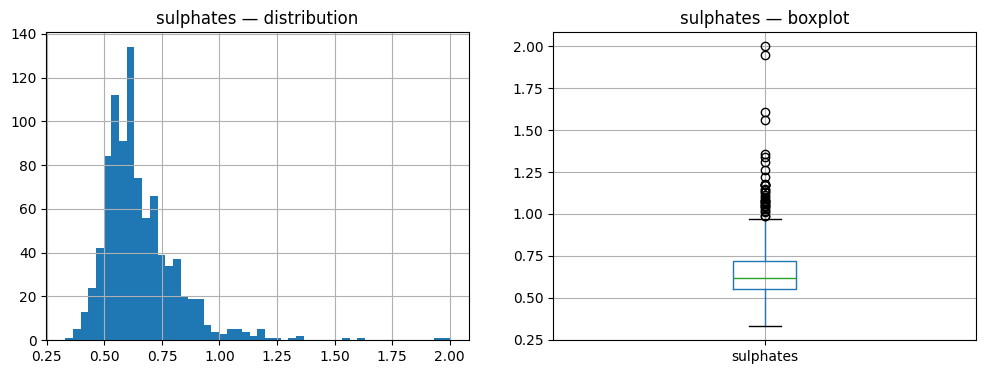

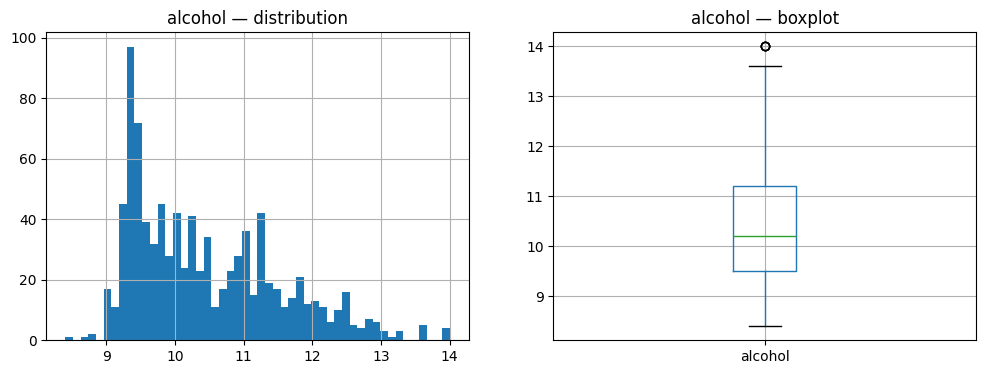

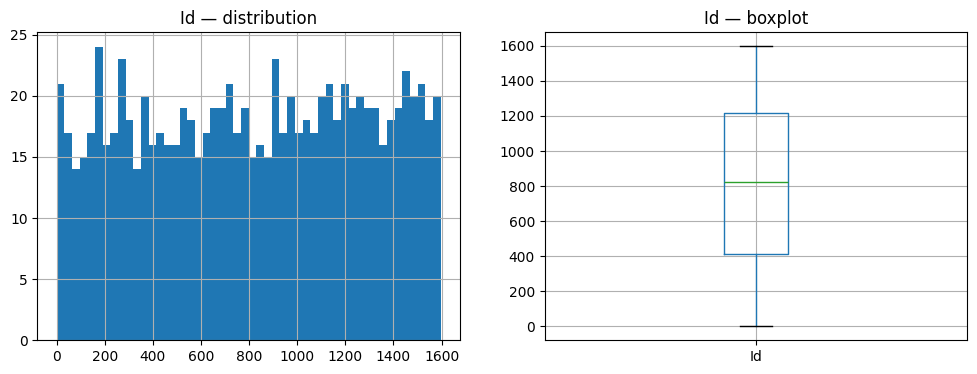

In [8]:
# Вычертить оригинал, написать пометку о логарифмических распределениях и что буду делать в preprocess.py
import matplotlib.pyplot as plt

for col in data.select_dtypes(include=['float64', 'int64']).columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Гистограмма
    data[col].hist(bins=50, ax=axes[0])
    axes[0].set_title(f'{col} — distribution')
    
    # Box plot
    data.boxplot(column=col, ax=axes[1])
    axes[1].set_title(f'{col} — boxplot')
    
    plt.show()

After analyzing the feature distribution graphs, I noticed several important aspects:
1. Some features are not normally distributed.
2. The features have different scales.
3. There are almost no outliers; we'll ignore them for now.
4. Remove Id.

Based on this, we work with the feature distribution and their scale in preprocess.py.

# Comparison of processed and stock data

In [9]:
preprocessor = get_preprocessor(config)
X = data.drop('Id', axis=1)
X_processed = preprocessor.fit_transform(X)
scale_cols = config['preprocess']['scale_cols']
log_cols = config['preprocess']['log_cols']
processed_names = scale_cols + [f'{col}_log' for col in log_cols]
df_processed = pd.DataFrame(X_processed, columns=processed_names)


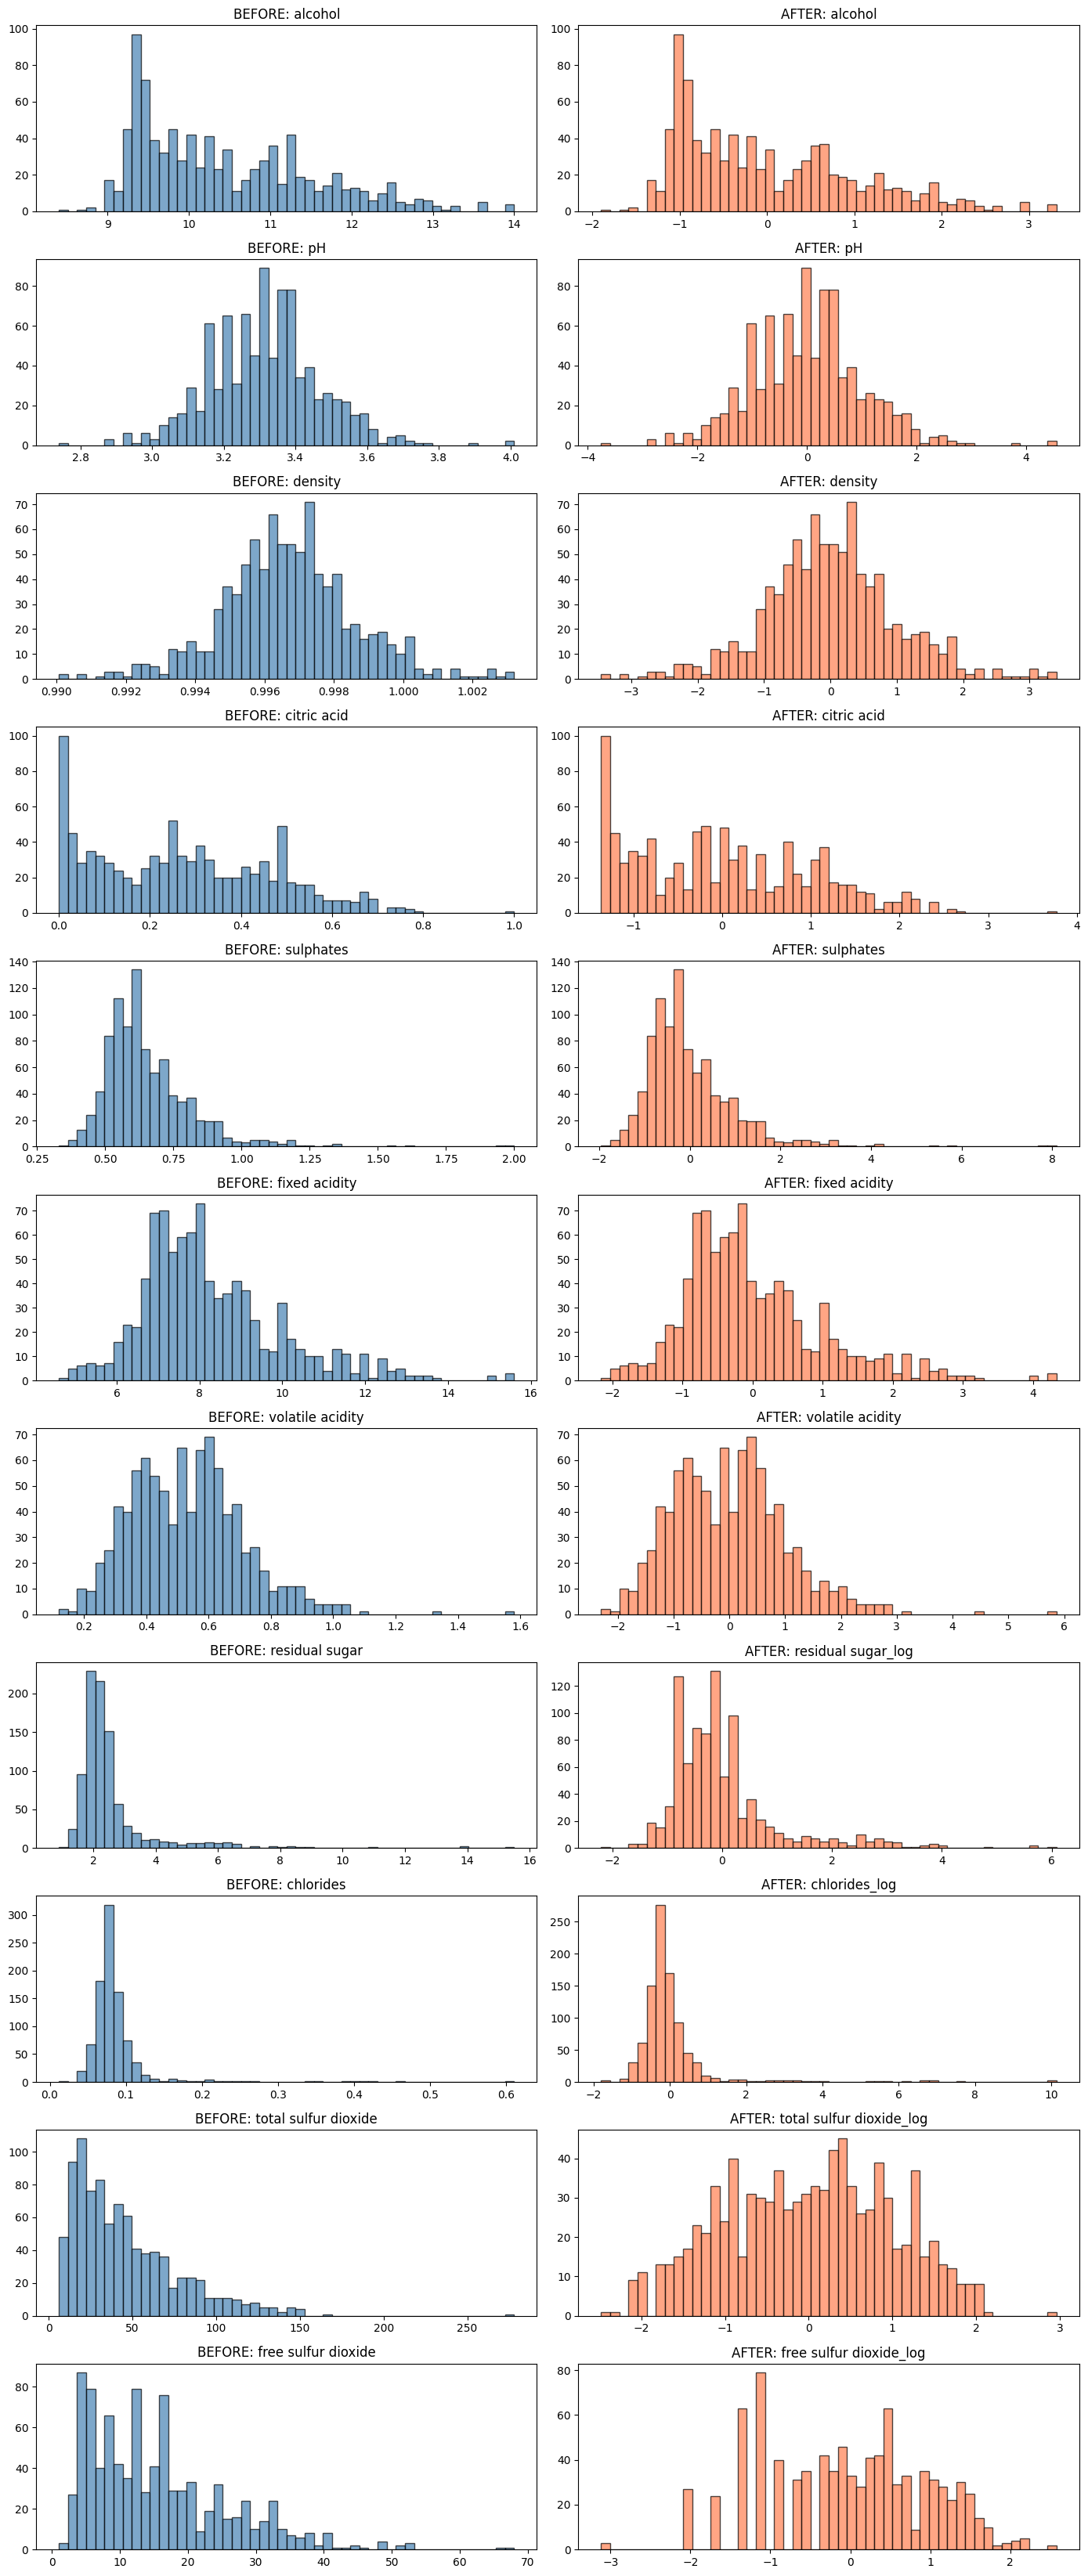

In [10]:
# Вычертить оригинал в сравненнии с препроцессом 
scale_cols = config['preprocess']['scale_cols']
log_cols = config['preprocess']['log_cols']

n_pairs = len(scale_cols) + len(log_cols)
fig, axes = plt.subplots(n_pairs, 2, figsize=(14, 3 * n_pairs))

idx = 0
# Масштабируемые колонки (имена не меняются)
for col in scale_cols:
    if col in data.columns and col in df_processed.columns:
        axes[idx, 0].hist(data[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx, 0].set_title(f'BEFORE: {col}')
        axes[idx, 1].hist(df_processed[col], bins=50, edgecolor='black', alpha=0.7, color='coral')
        axes[idx, 1].set_title(f'AFTER: {col}')
        idx += 1

# Логарифмируемые колонки (имена меняются)
for col in log_cols:
    col_after = f'{col}_log'
    if col in data.columns and col_after in df_processed.columns:
        axes[idx, 0].hist(data[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx, 0].set_title(f'BEFORE: {col}')
        axes[idx, 1].hist(df_processed[col_after], bins=50, edgecolor='black', alpha=0.7, color='coral')
        axes[idx, 1].set_title(f'AFTER: {col_after}')
        idx += 1

plt.tight_layout()
plt.show()

# Correlation Analisysis

Now let's look at the correlation between the features, as well as the dependencies between the features and the target.

In [11]:
X_y_data_unprocessed = data.copy()
X_y_data_unprocessed['quality'] = labels
corr_matrix = X_y_data_unprocessed.corr(numeric_only=True)
corr_matrix['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.481643
sulphates               0.265516
citric acid             0.224386
fixed acidity           0.095843
Id                      0.063415
residual sugar         -0.021126
pH                     -0.027518
free sulfur dioxide    -0.051602
chlorides              -0.138725
total sulfur dioxide   -0.177014
density                -0.208828
volatile acidity       -0.426460
Name: quality, dtype: float64

At this stage, we can note a moderately high absolute value linear correlation with the key feature values: alcohol and volatile acidity. 

Unfortunately, viewing the numerical values ​​of the Pearson correlation matrix can give us the wrong impression of the unimportance of features with low absolute value correlations. However, the relationship between them may be nonlinear. Therefore, let's plot the scatter_matrix for all features to see what kind of relationship, other than linear, there might be between the features and the target.

In [39]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# features = [col for col in X_y_data_unprocessed.columns if col != 'quality']

# for col in features:
#     plt.figure(figsize=(10, 4))
#     sns.stripplot(x='quality', y=col, data=X_y_data_unprocessed, 
#                   jitter=True, alpha=0.3, size=3)
#     plt.title(f'{col} vs quality (stripplot)')
#     plt.show()

Looking at the graph, it seems to me that some variables may have a quadratic dependence on the target.

 I'll check this for each feature that raised my suspicions. I'll use the R2 score and compare the values ​​for the stock features and their polynomials.

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

for col in ['residual sugar', 'free sulfur dioxide', 'total sulfur dioxide']:
    X_col = X_y_data_unprocessed[[col]]
    
    # Линейная регрессия
    lr = LinearRegression().fit(X_col, labels)
    r2_linear = r2_score(labels, lr.predict(X_col))
    
    # Полиномиальная степень 2
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X_col)
    lr_poly = LinearRegression().fit(X_poly, labels)
    r2_poly = r2_score(labels, lr_poly.predict(X_poly))
    
    improvement = r2_poly - r2_linear
    print(f"{col:25s} | linear R²: {r2_linear:.4f} | poly R²: {r2_poly:.4f} | +{improvement:.4f}")

residual sugar            | linear R²: 0.0004 | poly R²: 0.0013 | +0.0009
free sulfur dioxide       | linear R²: 0.0027 | poly R²: 0.0027 | +0.0000
total sulfur dioxide      | linear R²: 0.0313 | poly R²: 0.0357 | +0.0043


The analysis showed that, contrary to my expectations, raising these features to any power doesn't improve the model's performance, but rather leads to overfitting. Therefore, for this dataset, the necessary and sufficient set of transformations is taking the logarithm of features with non-normal distributions, as well as feature scaling. I also don't think that matching any features will yield positive results, so we'll avoid feature engineering.